In [1]:
!pip install xgboost -q

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

from xgboost import XGBClassifier

os.makedirs("plots", exist_ok=True)
os.makedirs("results", exist_ok=True)
os.makedirs("models", exist_ok=True)

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/Colab\ Notebooks/fraud-detection


/content/drive/MyDrive/Colab Notebooks/fraud-detection


In [4]:
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (227845, 30)
Test shape: (56962, 30)


In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
ratio = (y_train == 0).sum() / (y_train == 1).sum()
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=3000))
    ]),
    "Random Forest": RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
),

"XGBoost": XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    tree_method="hist",
    eval_metric="logloss",
    random_state=42
)
}


results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_probs = model.predict_proba(X_test)[:, 1]

    roc = roc_auc_score(y_test, y_probs)
    pr = average_precision_score(y_test, y_probs)

    results.append([name, roc, pr])

results_df = pd.DataFrame(results, columns=["Model", "ROC_AUC", "PR_AUC"])
results_df

,Model,ROC_AUC,PR_AUC
0,Logistic Regression,0.960549,0.741382
1,Random Forest,0.952908,0.854200
2,XGBoost,0.983183,0.727027


In [7]:
results_df.to_csv("results/baseline_results.csv", index=False)

In [8]:
def plot_roc_curve(model_name, y_true, y_probs):
    fpr, tpr, _ = roc_curve(y_true, y_probs)

    plt.figure()
    plt.plot(fpr, tpr, label=f"{model_name}")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend()
    plt.savefig(f"plots/roc_{model_name}.png")
    plt.show()

In [9]:
def plot_pr_curve(model_name, y_true, y_probs):
    precision, recall, _ = precision_recall_curve(y_true, y_probs)

    plt.figure()
    plt.plot(recall, precision, label=f"{model_name}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve - {model_name}")
    plt.legend()
    plt.savefig(f"plots/pr_{model_name}.png")
    plt.show()


In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_heatmap(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.savefig(f"plots/cm_{model_name}.png")
    plt.show()

In [11]:
def plot_prob_dist(model_name, y_probs, y_true):
    plt.figure()

    plt.hist(y_probs[y_true == 0], bins=50, alpha=0.6, label="Class 0")
    plt.hist(y_probs[y_true == 1], bins=50, alpha=0.6, label="Class 1")

    plt.xlabel("Predicted Probability")
    plt.ylabel("Count")
    plt.title(f"Probability Distribution - {model_name}")
    plt.legend()
    plt.savefig(f"plots/prob_dist_{model_name}.png")
    plt.show()

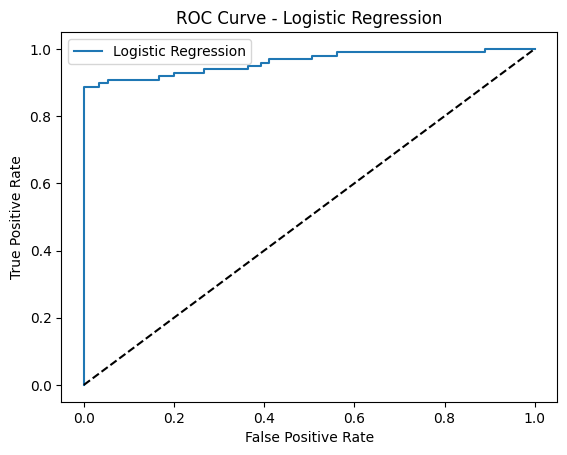

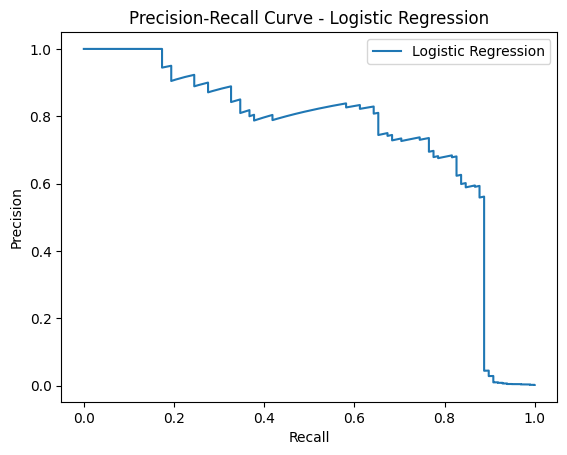

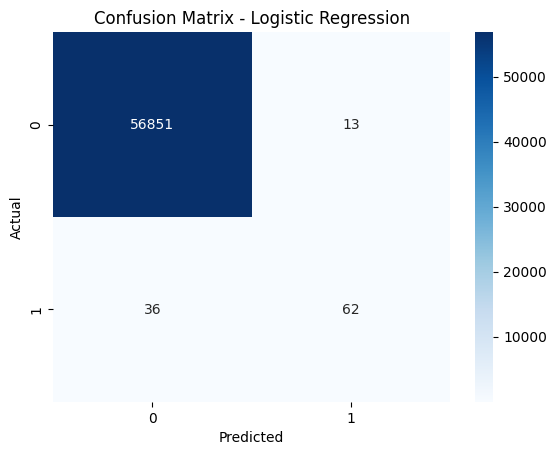

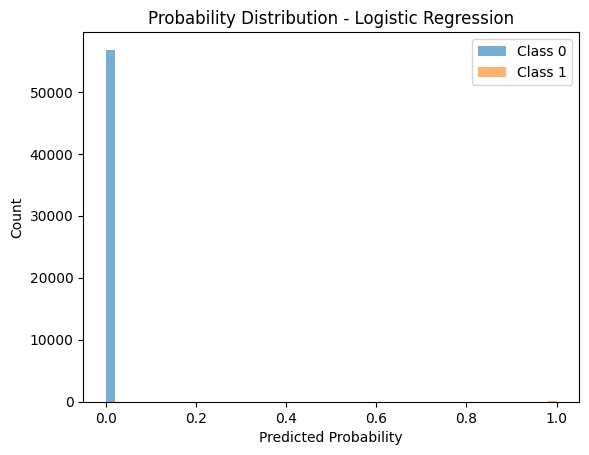

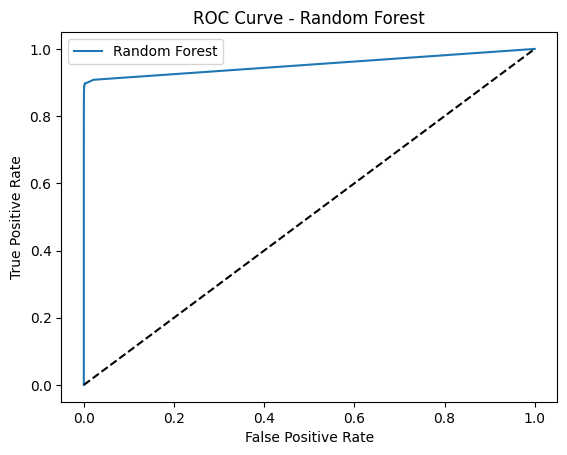

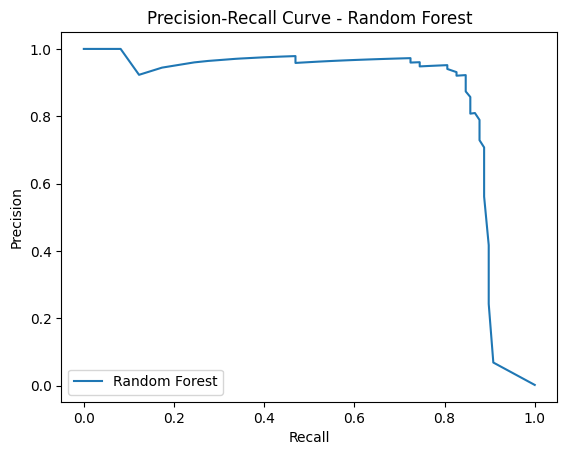

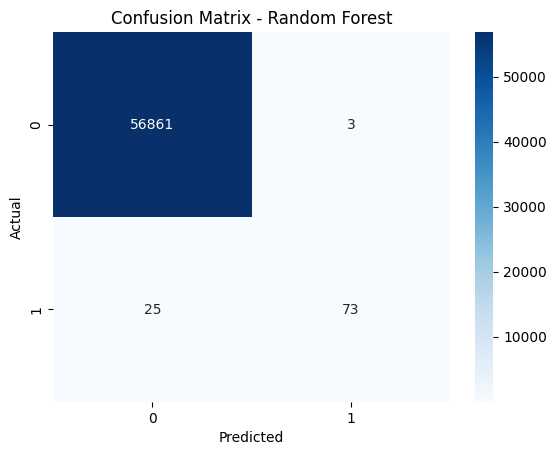

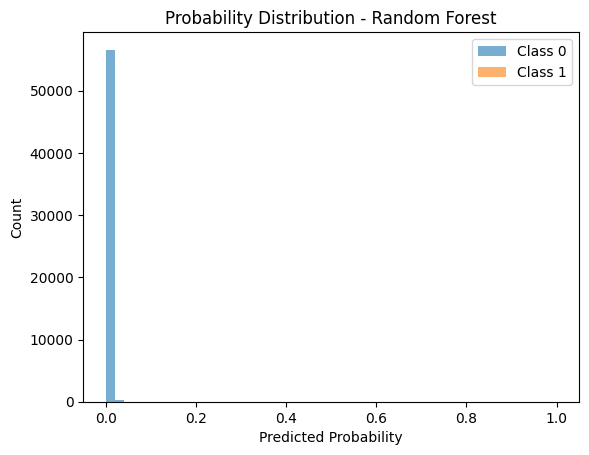

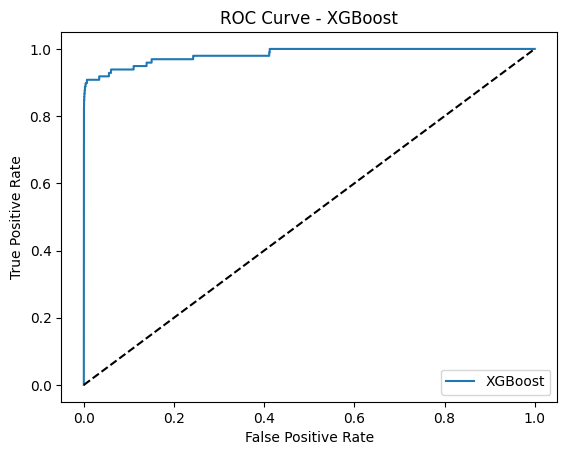

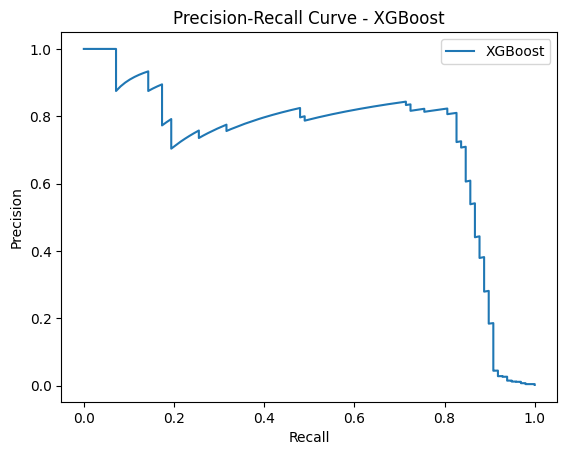

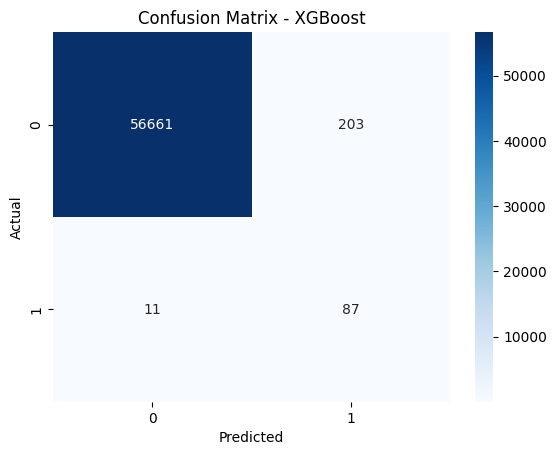

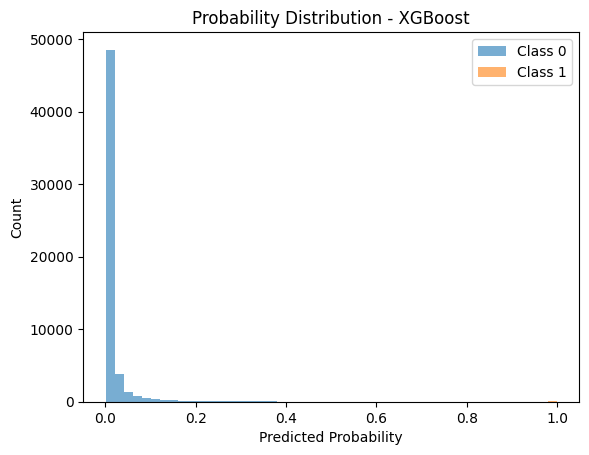

In [12]:
for name, model in models.items():
    model.fit(X_train, y_train)

    y_probs = model.predict_proba(X_test)[:, 1]
    y_preds = model.predict(X_test)

    plot_roc_curve(name, y_test, y_probs)
    plot_pr_curve(name, y_test, y_probs)
    plot_confusion_heatmap(name, y_test, y_preds)
    plot_prob_dist(name, y_probs, y_test)